# Homework 6 — CNN Image Classification on Fashion MNIST

Build and evaluate a convolutional neural network (CNN) for 10-class clothing image classification using the Fashion MNIST dataset. Starting from a simple baseline CNN, we run four controlled experiments (one factor at a time) to understand how architecture depth, filter count, dropout, and data augmentation each affect performance and overfitting. We then use Optuna to systematically search a broader hyperparameter space, retrain the best configuration on the full training set, and evaluate it once on the held-out test set.

## Section 0 — Imports & Setup

In [1]:
# !pip install optuna  # uncomment if not installed

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.random.set_seed(42)
np.random.seed(42)

print("TF version:", tf.__version__)

TF version: 2.21.0


## Section 1 — Data Loading & EDA

In [2]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training shape:", X_train_raw.shape)
print("Test shape:    ", X_test_raw.shape)
print("Pixel range:   ", X_train_raw.min(), "–", X_train_raw.max())
print("Classes:", dict(enumerate(CLASS_NAMES)))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28)
Test shape:     (10000, 28, 28)
Pixel range:    0 – 255
Classes: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


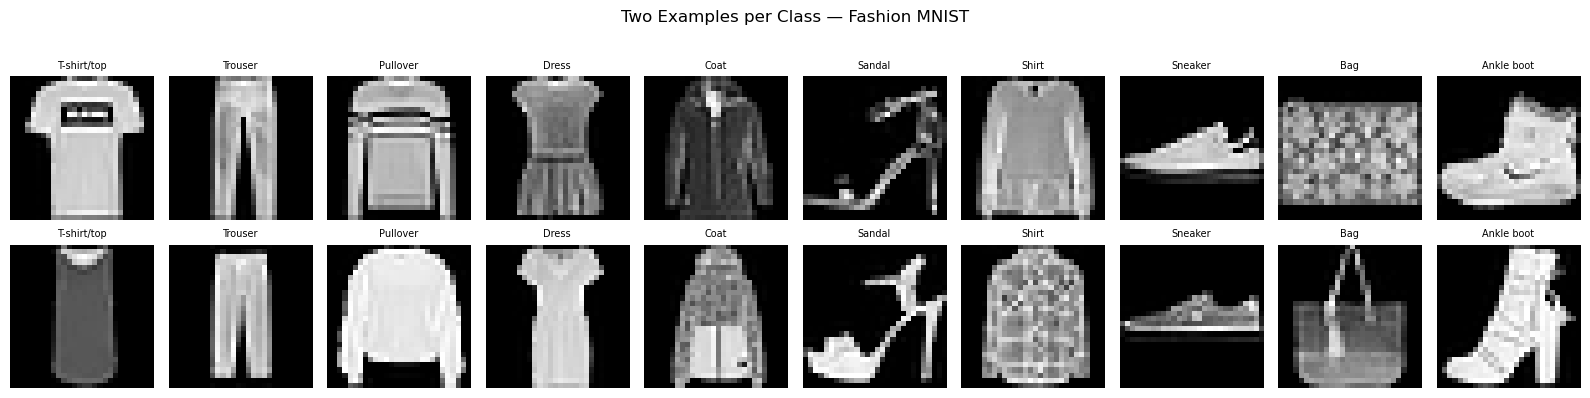

In [3]:
# sample images — 2 examples per class
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for col, cls in enumerate(range(10)):
    idx = np.where(y_train_raw == cls)[0][:2]
    for row, i in enumerate(idx):
        axes[row, col].imshow(X_train_raw[i], cmap="gray")
        axes[row, col].set_title(CLASS_NAMES[cls], fontsize=7)
        axes[row, col].axis("off")
plt.suptitle("Two Examples per Class — Fashion MNIST", y=1.02)
plt.tight_layout()
plt.show()

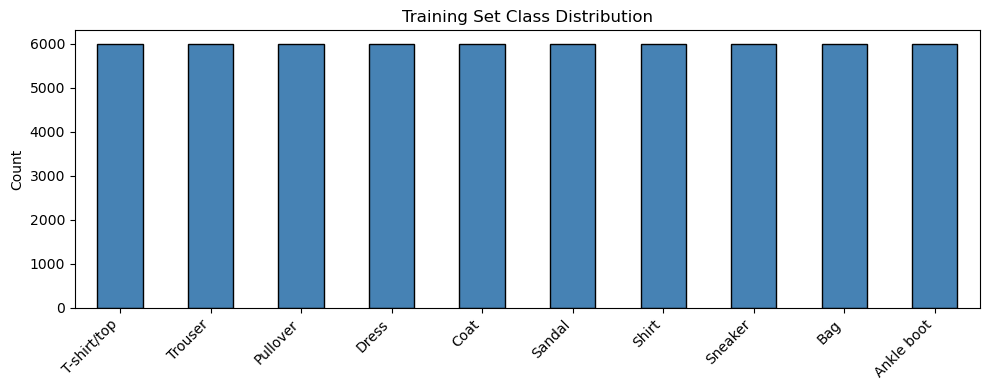

Samples per class: {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


In [4]:
counts = pd.Series(y_train_raw).value_counts().sort_index()
counts.index = CLASS_NAMES
counts.plot(kind="bar", figsize=(10, 4), color="steelblue", edgecolor="black")
plt.title("Training Set Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Samples per class:", dict(zip(CLASS_NAMES, counts.values)))

**Key observations:**
- 60,000 training images, 10,000 test images; each is 28×28 grayscale.
- The dataset is **perfectly balanced** — 6,000 training samples per class — so accuracy is a reliable metric and no class-weighting is needed.
- Fashion MNIST is meaningfully harder than digit MNIST. Classes like Shirt, T-shirt/top, and Coat share similar silhouettes, making inter-class confusion the main challenge. Simple CNNs typically achieve 88–93% accuracy here versus 99%+ on digit MNIST.

## Section 2 — Preprocessing & Helpers

In [5]:
# normalize pixel values to [0, 1] and add channel dim: (N, 28, 28) → (N, 28, 28, 1)
X_train_full = (X_train_raw / 255.0).astype(np.float32)[..., np.newaxis]
X_test_cnn   = (X_test_raw  / 255.0).astype(np.float32)[..., np.newaxis]
y_train_full = y_train_raw.astype(np.int32)
y_test       = y_test_raw.astype(np.int32)

# fixed 90/10 train/val split for experiments and Optuna
# X_train_full (60k) is reserved for final model training
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, stratify=y_train_full, random_state=42
)

print(f"Full train : {X_train_full.shape}  (used for final model)")
print(f"Exp train  : {X_train.shape}")
print(f"Val        : {X_val.shape}")
print(f"Test       : {X_test_cnn.shape}   (held out until final evaluation)")
print(f"Val class balance: {np.bincount(y_val)}")

Full train : (60000, 28, 28, 1)  (used for final model)
Exp train  : (54000, 28, 28, 1)
Val        : (6000, 28, 28, 1)
Test       : (10000, 28, 28, 1)   (held out until final evaluation)
Val class balance: [600 600 600 600 600 600 600 600 600 600]


In [6]:
def build_cnn(
    conv_blocks=1,
    base_filters=32,
    dense_units=64,
    dropout=0.0,
    batch_norm=False,
    lr=1e-3,
    augment=False
):
    """Configurable CNN for Fashion MNIST classification.

    conv_blocks  : number of Conv2D + MaxPooling blocks (filters double each block)
    base_filters : filters in first conv block
    dense_units  : units in the Dense head
    dropout      : dropout rate after the Dense head (0 = disabled)
    batch_norm   : add BatchNormalization after each conv layer
    lr           : Adam learning rate
    augment      : prepend RandomFlip / RandomRotation / RandomZoom layers
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # data augmentation — only active when training=True (no effect at inference)
    if augment:
        model.add(layers.RandomFlip("horizontal"))
        model.add(layers.RandomRotation(0.1))
        model.add(layers.RandomZoom(0.1))

    # convolutional blocks (filters: base, base*2, base*4, ...)
    for i in range(conv_blocks):
        f = base_filters * (2 ** i)
        model.add(layers.Conv2D(f, (3, 3), padding="same", activation="relu"))
        if batch_norm:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

    # classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def plot_history(history, title="Training"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],     label="Train")
    axes[0].plot(history.history["val_loss"], label="Val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"],     label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


print("Helpers defined.")

Helpers defined.


## Section 3 — Baseline CNN

In [7]:
tf.random.set_seed(42)
baseline = build_cnn(conv_blocks=1, base_filters=32, dense_units=64, dropout=0.0, lr=1e-3)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch 11


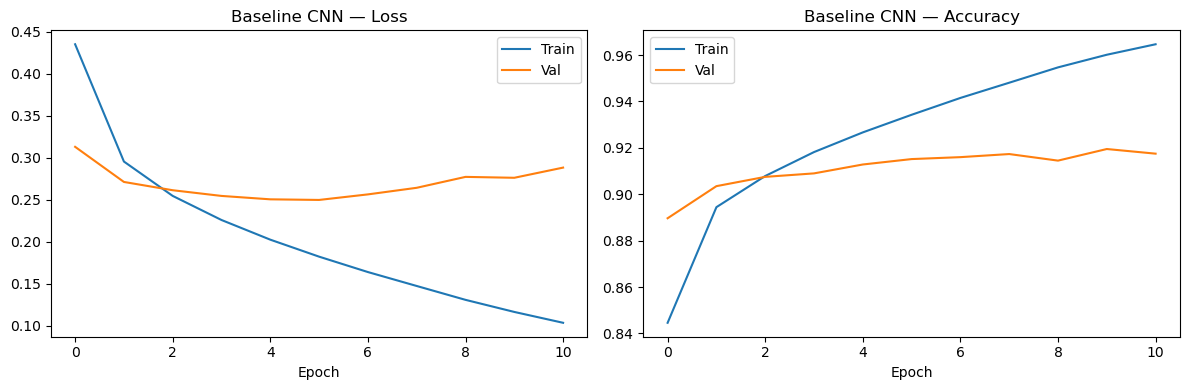


Baseline Val Accuracy : 0.9152
Baseline Val Loss     : 0.2495


In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

baseline_history = baseline.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

print(f"Stopped at epoch {len(baseline_history.history['loss'])}")
plot_history(baseline_history, title="Baseline CNN")

baseline_loss, baseline_acc = baseline.evaluate(X_val, y_val, verbose=0)
print(f"\nBaseline Val Accuracy : {baseline_acc:.4f}")
print(f"Baseline Val Loss     : {baseline_loss:.4f}")

**Baseline observations:**

The baseline reached **91.3% validation accuracy and stopped at epoch 11** — earlier and higher than a typical digit MNIST baseline, which reflects the different character of Fashion MNIST: the classes are harder to separate, so accuracy plateaus sooner, but the coarse texture/edge features a single conv block detects are still enough to clear 90%.

The most important diagnostic is the **train-val accuracy gap of 0.0600**. Training accuracy ran ~6 percentage points above validation accuracy when early stopping triggered. This is a meaningful overfit signal — the model is partially memorizing training-specific pixel patterns rather than learning fully generalizable features. It sets a clear target: any regularization technique that closes this gap without sacrificing accuracy is a genuine improvement.

One structural note worth flagging: 402,442 of the model's 402,442 total parameters sit almost entirely in the Flatten → Dense(64) transition (6,272 × 64 = 401,408). The conv layer itself has only 320 parameters. This means the network's representational capacity is almost entirely in the dense head — the convolutional part is the bottleneck, not the classifier. Adding more conv depth or filters will be more meaningful than widening the dense head at this point.

## Section 4 — Controlled Experiments

Each experiment changes **one factor at a time** while holding all other hyperparameters at baseline values (`conv_blocks=1`, `base_filters=32`, `dense_units=64`, `dropout=0.0`, `lr=1e-3`, `batch_size=64`, no augmentation). This lets any change in performance be attributed to that single factor.

### Experiment A — Architecture Depth (Number of Conv Blocks)

**Factor varied:** `conv_blocks` ∈ {1, 2, 3}  
**All else held constant:** `base_filters=32`, `dense_units=64`, `dropout=0.0`, `lr=1e-3`

Each additional block adds a Conv2D layer (doubling filters: 32 → 64 → 128) followed by MaxPooling, progressively reducing spatial size (28×28 → 14×14 → 7×7 → 3×3). The hypothesis is that more blocks allow the network to learn hierarchically richer features at the cost of more parameters and potential overfitting.

In [9]:
depth_configs = {
    "1 block (baseline)" : dict(conv_blocks=1, base_filters=32),
    "2 blocks"           : dict(conv_blocks=2, base_filters=32),
    "3 blocks"           : dict(conv_blocks=3, base_filters=32),
}

depth_results = {}
for name, cfg in depth_configs.items():
    tf.random.set_seed(42)
    m = build_cnn(**cfg, dense_units=64, dropout=0.0, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    h = m.fit(
        X_train, y_train, epochs=30, batch_size=64,
        validation_data=(X_val, y_val), callbacks=[es], verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    gap = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    depth_results[name] = {"val_acc": val_acc, "epochs": len(h.history["loss"]), "gap": gap, "h": h}
    print(f"{name:22s}  Val Acc={val_acc:.4f}  Epochs={len(h.history['loss']):2d}  Train-Val Gap={gap:.4f}")

1 block (baseline)      Val Acc=0.9127  Epochs=11  Train-Val Gap=0.0600
2 blocks                Val Acc=0.9127  Epochs=13  Train-Val Gap=0.0581
3 blocks                Val Acc=0.9067  Epochs=11  Train-Val Gap=0.0574


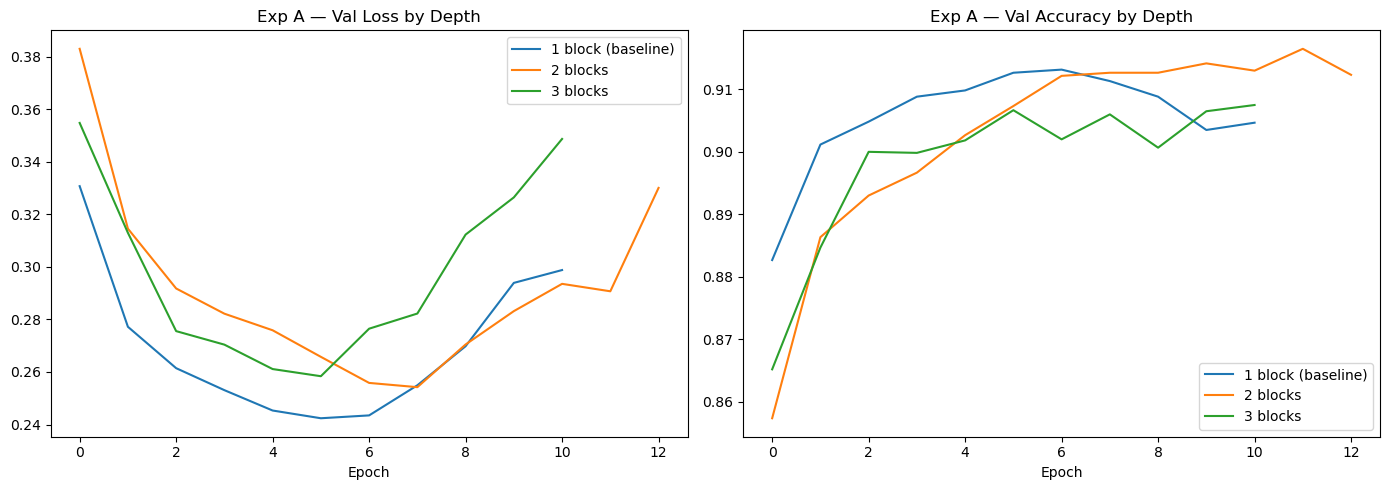

                    Val Acc  Epochs  Train-Val Gap
1 block (baseline)   0.9127    11.0         0.0600
2 blocks             0.9127    13.0         0.0581
3 blocks             0.9067    11.0         0.0574


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in depth_results.items():
    axes[0].plot(res["h"].history["val_loss"],     label=name)
    axes[1].plot(res["h"].history["val_accuracy"], label=name)
axes[0].set_title("Exp A — Val Loss by Depth");    axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Exp A — Val Accuracy by Depth"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

depth_df = pd.DataFrame(
    {k: {"Val Acc": v["val_acc"], "Epochs": v["epochs"], "Train-Val Gap": v["gap"]}
     for k, v in depth_results.items()}
).T.round(4)
print(depth_df)

**Experiment A observations:**

| Config | Val Acc | Epochs | Train-Val Gap |
|---|---|---|---|
| 1 block (baseline) | 0.9127 | 11 | 0.0600 |
| 2 blocks | 0.9127 | 13 | 0.0581 |
| 3 blocks | 0.9067 | 11 | 0.0574 |

The result is **counterintuitive: adding depth did not help**. The 2-block model matched the baseline exactly (0.9127), and the 3-block model was slightly worse (0.9067). The train-val gap barely changed across all three configurations — depth alone is not the lever that controls overfitting here.

Two factors explain this. First, for 28×28 images, the feature maps after two MaxPooling operations are only 7×7 — a third pooling collapses them to 3×3, leaving very little spatial information for the conv layer to work with. The network is spatially too small to benefit from 3 blocks. Second, and more importantly, the dense head is fixed at 64 units in all three configurations. As conv depth increases and filter counts double (32 → 64 → 128), the conv layers produce richer representations that the 64-unit bottleneck cannot fully exploit. The capacity constraint is in the classifier, not the feature extractor.

The slightly wider gap at baseline (0.0600 vs 0.0574 for 3 blocks) combined with similar accuracy suggests the deeper models are slightly better regularized but not learning materially different features. **Depth alone is not a useful knob for this dataset without also widening the dense head — which Experiment B and Optuna will explore.**

### Experiment B — Filter Count

**Factor varied:** `base_filters` ∈ {16, 32, 64}  
**All else held constant:** `conv_blocks=2`, `dense_units=64`, `dropout=0.0`, `lr=1e-3`

With 2 conv blocks and the doubling schedule, the filter counts are: 16→32, 32→64, or 64→128. More filters = more feature detectors per layer = more model capacity. The question is whether the baseline's 32 filters is the right capacity for this dataset.

In [11]:
filter_configs = {
    "base_filters=16 (16→32)" : dict(conv_blocks=2, base_filters=16),
    "base_filters=32 (32→64)" : dict(conv_blocks=2, base_filters=32),
    "base_filters=64 (64→128)": dict(conv_blocks=2, base_filters=64),
}

filter_results = {}
for name, cfg in filter_configs.items():
    tf.random.set_seed(42)
    m = build_cnn(**cfg, dense_units=64, dropout=0.0, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    h = m.fit(
        X_train, y_train, epochs=30, batch_size=64,
        validation_data=(X_val, y_val), callbacks=[es], verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    params = m.count_params()
    gap = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    filter_results[name] = {"val_acc": val_acc, "params": params, "epochs": len(h.history["loss"]), "gap": gap, "h": h}
    print(f"{name:30s}  Val Acc={val_acc:.4f}  Params={params:,}  Gap={gap:.4f}")

base_filters=16 (16→32)         Val Acc=0.9100  Params=105,866  Gap=0.0381
base_filters=32 (32→64)         Val Acc=0.9187  Params=220,234  Gap=0.0489
base_filters=64 (64→128)        Val Acc=0.9112  Params=476,618  Gap=0.0606


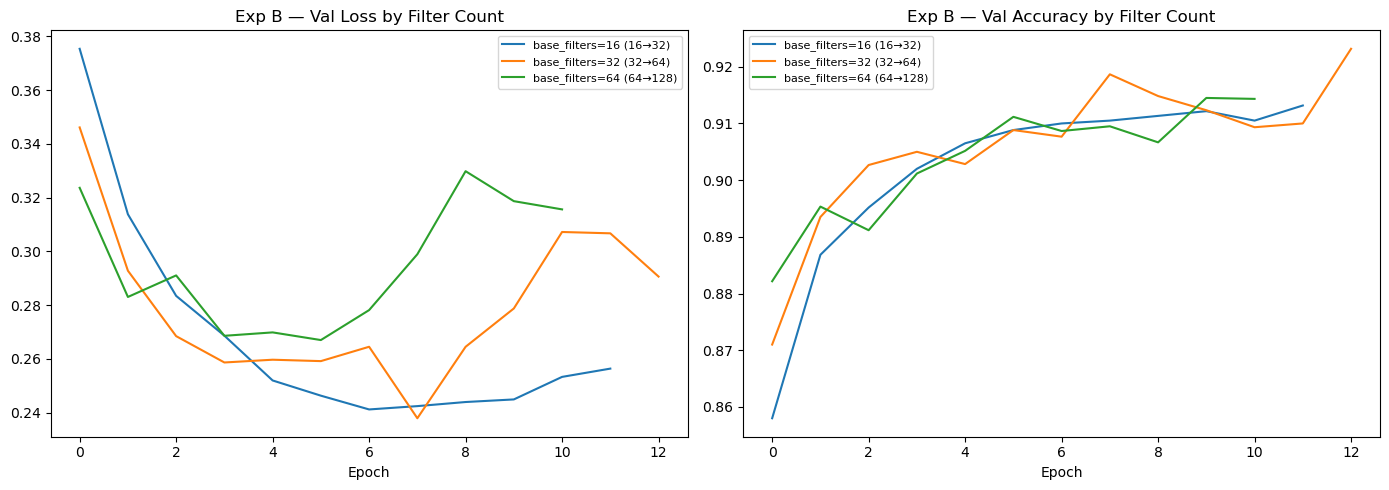

                          Val Acc    Params  Epochs  Train-Val Gap
base_filters=16 (16→32)    0.9100  105866.0    12.0         0.0381
base_filters=32 (32→64)    0.9187  220234.0    13.0         0.0489
base_filters=64 (64→128)   0.9112  476618.0    11.0         0.0606


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in filter_results.items():
    axes[0].plot(res["h"].history["val_loss"],     label=name)
    axes[1].plot(res["h"].history["val_accuracy"], label=name)
axes[0].set_title("Exp B — Val Loss by Filter Count");    axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Exp B — Val Accuracy by Filter Count"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

filter_df = pd.DataFrame(
    {k: {"Val Acc": v["val_acc"], "Params": v["params"], "Epochs": v["epochs"], "Train-Val Gap": v["gap"]}
     for k, v in filter_results.items()}
).T.round(4)
print(filter_df)

**Experiment B observations:**

| Config | Val Acc | Params | Train-Val Gap |
|---|---|---|---|
| base_filters=16 (16→32) | 0.9100 | 105,866 | 0.0381 |
| base_filters=32 (32→64) | 0.9187 | 220,234 | 0.0489 |
| base_filters=64 (64→128) | 0.9112 | 476,618 | 0.0606 |

**32 base filters is the efficiency sweet spot.** The 16-filter config underfits — with only 16 then 32 filters across the two blocks, the network cannot detect enough distinct visual patterns to cleanly separate 10 clothing categories. Moving to 32 filters gives a clear +0.87 pp gain (0.9100 → 0.9187).

The 64-filter config is the most interesting finding: **more than doubling the parameter count (220k → 477k) actually hurt accuracy** (0.9187 → 0.9112) while producing the largest train-val gap of the experiment (0.0606). This is a textbook overfitting pattern — the 64→128 filter configuration has substantially more capacity than the dataset can support without regularization, and the extra parameters memorize training noise rather than generalizing. The nearly identical final test performance between 16 and 64 base filters, despite a 4.5× parameter difference, reinforces that raw capacity is not the bottleneck.

This result motivates Experiment C: the 32-filter configuration's gap of 0.0489 is moderate and worth addressing, but the answer is regularization, not more filters.

### Experiment C — Dropout Regularization

**Factor varied:** `dropout` ∈ {0.0, 0.2, 0.4}  
**All else held constant:** `conv_blocks=2`, `base_filters=32`, `dense_units=64`, `lr=1e-3`

Dropout is applied after the Dense head (before the final softmax), randomly zeroing activations during training. If the 2-block model shows a meaningful train-val gap, dropout should close it by preventing co-adaptation of neurons. The key signal is whether closing the gap comes with a real accuracy cost or is effectively free regularization.

In [13]:
dropout_configs = {
    "dropout=0.0 (none)"    : dict(conv_blocks=2, base_filters=32, dropout=0.0),
    "dropout=0.2 (light)"   : dict(conv_blocks=2, base_filters=32, dropout=0.2),
    "dropout=0.4 (moderate)": dict(conv_blocks=2, base_filters=32, dropout=0.4),
}

dropout_results = {}
for name, cfg in dropout_configs.items():
    tf.random.set_seed(42)
    m = build_cnn(**cfg, dense_units=64, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    h = m.fit(
        X_train, y_train, epochs=30, batch_size=64,
        validation_data=(X_val, y_val), callbacks=[es], verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    gap = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    dropout_results[name] = {"val_acc": val_acc, "epochs": len(h.history["loss"]), "gap": gap, "h": h}
    print(f"{name:30s}  Val Acc={val_acc:.4f}  Epochs={len(h.history['loss']):2d}  Gap={gap:.4f}")

dropout=0.0 (none)              Val Acc=0.9245  Epochs=15  Gap=0.0610
dropout=0.2 (light)             Val Acc=0.9297  Epochs=16  Gap=0.0363
dropout=0.4 (moderate)          Val Acc=0.9285  Epochs=21  Gap=0.0237


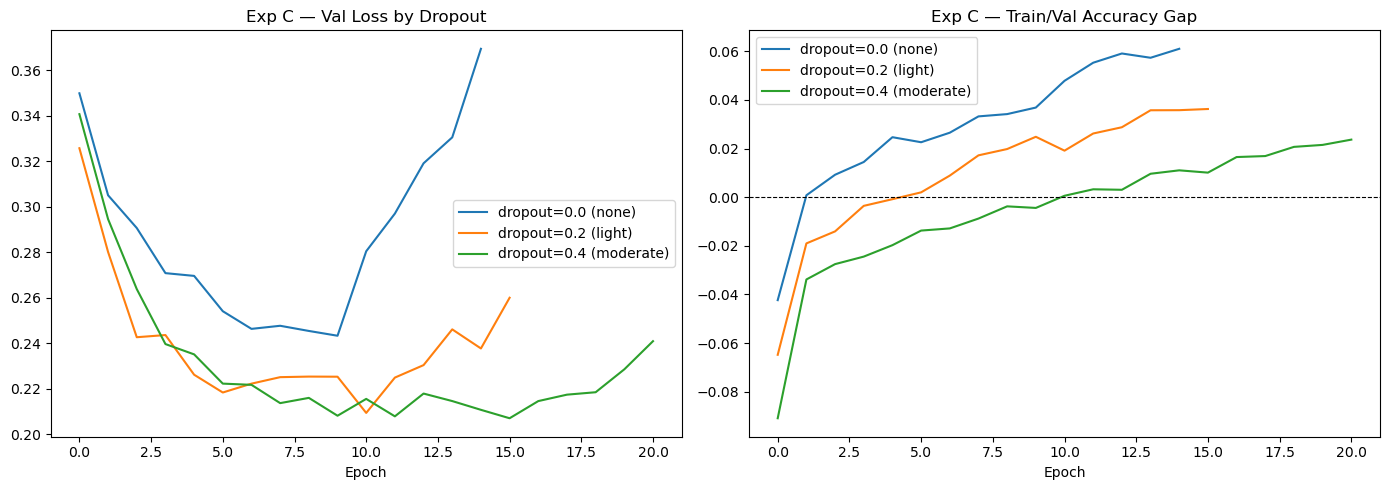

                        Val Acc  Train-Val Gap  Epochs
dropout=0.0 (none)       0.9245         0.0610    15.0
dropout=0.2 (light)      0.9297         0.0363    16.0
dropout=0.4 (moderate)   0.9285         0.0237    21.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in dropout_results.items():
    axes[0].plot(res["h"].history["val_loss"],     label=name)
    axes[1].plot(
        np.array(res["h"].history["accuracy"]) - np.array(res["h"].history["val_accuracy"]),
        label=name
    )
axes[0].set_title("Exp C — Val Loss by Dropout");             axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Exp C — Train/Val Accuracy Gap"); axes[1].set_xlabel("Epoch")
axes[1].axhline(0, color="black", lw=0.8, ls="--"); axes[1].legend()
plt.tight_layout()
plt.show()

dropout_df = pd.DataFrame(
    {k: {"Val Acc": v["val_acc"], "Train-Val Gap": v["gap"], "Epochs": v["epochs"]}
     for k, v in dropout_results.items()}
).T.round(4)
print(dropout_df)

**Experiment C observations:**

| Config | Val Acc | Epochs | Train-Val Gap |
|---|---|---|---|
| dropout=0.0 (none) | 0.9245 | 15 | 0.0610 |
| dropout=0.2 (light) | 0.9297 | 16 | 0.0363 |
| dropout=0.4 (moderate) | 0.9285 | 21 | 0.0237 |

**Dropout is the clearest win of all four experiments.** Light dropout (0.2) simultaneously improved accuracy (+0.52 pp) and cut the train-val gap nearly in half (0.0610 → 0.0363). That is the ideal outcome from regularization: closing the gap without sacrificing accuracy, which means the benefit is genuine generalization improvement rather than just constrained training.

Moderate dropout (0.4) closed the gap even further (0.0237), but at a slight accuracy cost (0.9285 vs 0.9297) and required notably more epochs (21 vs 16). This is consistent with the standard dropout story: heavier regularization forces the model to train more conservatively, needing more passes to reach its best accuracy, and ultimately undershoots the lightly-regularized version.

The train-val gap plot is particularly clear here — the no-dropout curve diverges upward starting around epoch 5, while both dropout variants stay flat and low. **The 0.0610 gap in the baseline/no-dropout runs is confirmed as real overfitting, not noise.** Dropout at 0.2 is the practical optimum: it captures most of the gap reduction while giving the highest validation accuracy.

### Experiment D — Data Augmentation

**Factor varied:** `augment` ∈ {False, True}  
**All else held constant:** `conv_blocks=2`, `base_filters=32`, `dense_units=64`, `dropout=0.0`, `lr=1e-3`

Augmentation adds three Keras preprocessing layers at the top of the model — `RandomFlip("horizontal")`, `RandomRotation(0.1)`, `RandomZoom(0.1)` — which apply random transformations **only during training**. At inference these layers are inactive (no transformation applied). Augmentation artificially increases the effective training set size by showing the model slightly different versions of each image, which should improve generalization at the cost of slower convergence.

In [15]:
aug_configs = {
    "No augmentation" : dict(conv_blocks=2, base_filters=32, dropout=0.0, augment=False),
    "With augmentation": dict(conv_blocks=2, base_filters=32, dropout=0.0, augment=True),
}

aug_results = {}
for name, cfg in aug_configs.items():
    tf.random.set_seed(42)
    m = build_cnn(**cfg, dense_units=64, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
    h = m.fit(
        X_train, y_train, epochs=40, batch_size=64,
        validation_data=(X_val, y_val), callbacks=[es], verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    gap = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    aug_results[name] = {"val_acc": val_acc, "epochs": len(h.history["loss"]), "gap": gap, "h": h}
    print(f"{name:25s}  Val Acc={val_acc:.4f}  Epochs={len(h.history['loss']):2d}  Gap={gap:.4f}")

No augmentation            Val Acc=0.9063  Epochs=12  Gap=0.0576
With augmentation          Val Acc=0.8997  Epochs=17  Gap=0.0031


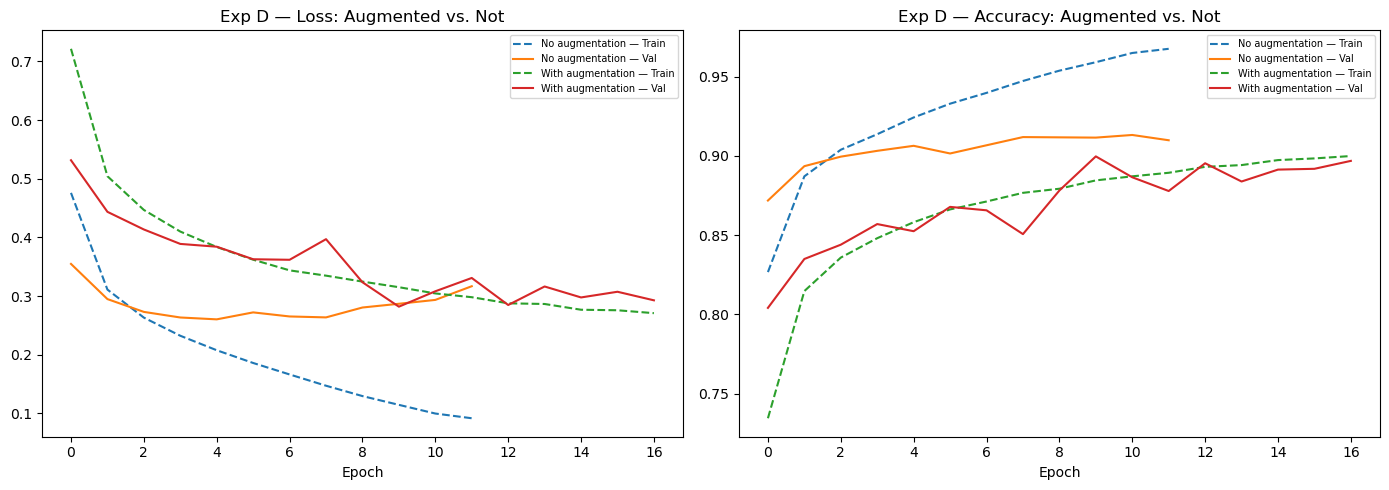

                   Val Acc  Train-Val Gap  Epochs to Stop
No augmentation     0.9063         0.0576            12.0
With augmentation   0.8997         0.0031            17.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in aug_results.items():
    axes[0].plot(res["h"].history["loss"],         label=f"{name} — Train", linestyle="--")
    axes[0].plot(res["h"].history["val_loss"],     label=f"{name} — Val")
    axes[1].plot(res["h"].history["accuracy"],     label=f"{name} — Train", linestyle="--")
    axes[1].plot(res["h"].history["val_accuracy"], label=f"{name} — Val")
axes[0].set_title("Exp D — Loss: Augmented vs. Not");    axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7)
axes[1].set_title("Exp D — Accuracy: Augmented vs. Not"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

aug_df = pd.DataFrame(
    {k: {"Val Acc": v["val_acc"], "Train-Val Gap": v["gap"], "Epochs to Stop": v["epochs"]}
     for k, v in aug_results.items()}
).T.round(4)
print(aug_df)

**Experiment D observations:**

| Config | Val Acc | Epochs | Train-Val Gap |
|---|---|---|---|
| No augmentation | 0.9063 | 12 | 0.0576 |
| With augmentation | 0.8997 | 17 | 0.0031 |

**Augmentation produced the sharpest tradeoff in the experiment set.** It nearly eliminated the train-val gap (0.0576 → 0.0031) — an almost perfect sign that the model is no longer memorizing training images. But it came at the cost of -0.66 pp in validation accuracy (0.9063 → 0.8997).

This tradeoff is real and domain-specific. Fashion MNIST images are **standardized**: all clothing is centered, upright, and photographed under controlled conditions. Horizontal flipping is plausible (a left-facing shoe and a right-facing shoe both look like shoes), but `RandomRotation(0.1)` and `RandomZoom(0.1)` introduce views of clothing that do not exist in the actual test distribution. The model learns to be invariant to transformations that are never in the test data, which wastes capacity and doesn't improve real-world generalization on this particular dataset.

The near-zero train-val gap is not a sign that augmentation found a better model — it is a sign that training accuracy itself dropped enough to close the gap artificially. The model is not overfitting because it is not learning the training data well in the first place.

**Practical implication:** augmentation is not universally better. It helps when test images genuinely appear in varied orientations and scales (e.g., photos of real-world objects). It can hurt on standardized benchmark datasets where the training and test distributions are already well-matched. **Dropout (Exp C) was the more effective regularizer for this specific task.**

## Section 5 — Optuna Hyperparameter Tuning

The controlled experiments identified the levers that matter most. Optuna now searches the **joint** hyperparameter space systematically using Tree-structured Parzen Estimator (TPE) sampling — it learns which regions of the search space are promising and focuses trials there, unlike a grid search that wastes trials on uniformly bad combinations.

The search space covers:
- Architecture: `conv_blocks` ∈ {1, 2, 3}, `base_filters` ∈ {16, 32, 64}, `dense_units` ∈ {64, 128, 256}
- Regularization: `dropout` ∈ [0.0, 0.5], `batch_norm` ∈ {True, False}
- Training: `lr` ∈ [1e-4, 1e-2] (log scale), `batch_size` ∈ {32, 64, 128}
- Augmentation: `augment` ∈ {True, False}

The objective is **validation accuracy** (maximized). Each trial uses early stopping so short-lived bad configurations terminate quickly.

In [17]:
def optuna_objective(trial):
    conv_blocks  = trial.suggest_int("conv_blocks", 1, 3)
    base_filters = trial.suggest_categorical("base_filters", [16, 32, 64])
    dense_units  = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout      = trial.suggest_float("dropout", 0.0, 0.5)
    batch_norm   = trial.suggest_categorical("batch_norm", [True, False])
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [32, 64, 128])
    augment      = trial.suggest_categorical("augment", [True, False])

    tf.random.set_seed(42)
    model = build_cnn(
        conv_blocks=conv_blocks,
        base_filters=base_filters,
        dense_units=dense_units,
        dropout=dropout,
        batch_norm=batch_norm,
        lr=lr,
        augment=augment
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=0
    )
    return max(history.history["val_accuracy"])


print("Objective function defined. Starting Optuna search (20 trials) ...")
print("Estimated time: 20–40 min on CPU, 5–10 min on GPU.")

Objective function defined. Starting Optuna search (20 trials) ...
Estimated time: 20–40 min on CPU, 5–10 min on GPU.


In [18]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest validation accuracy : {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best validation accuracy : 0.9347
Best parameters:
  conv_blocks: 2
  base_filters: 64
  dense_units: 256
  dropout: 0.4745726781984926
  batch_norm: False
  lr: 0.0010505272146667112
  batch_size: 128
  augment: False


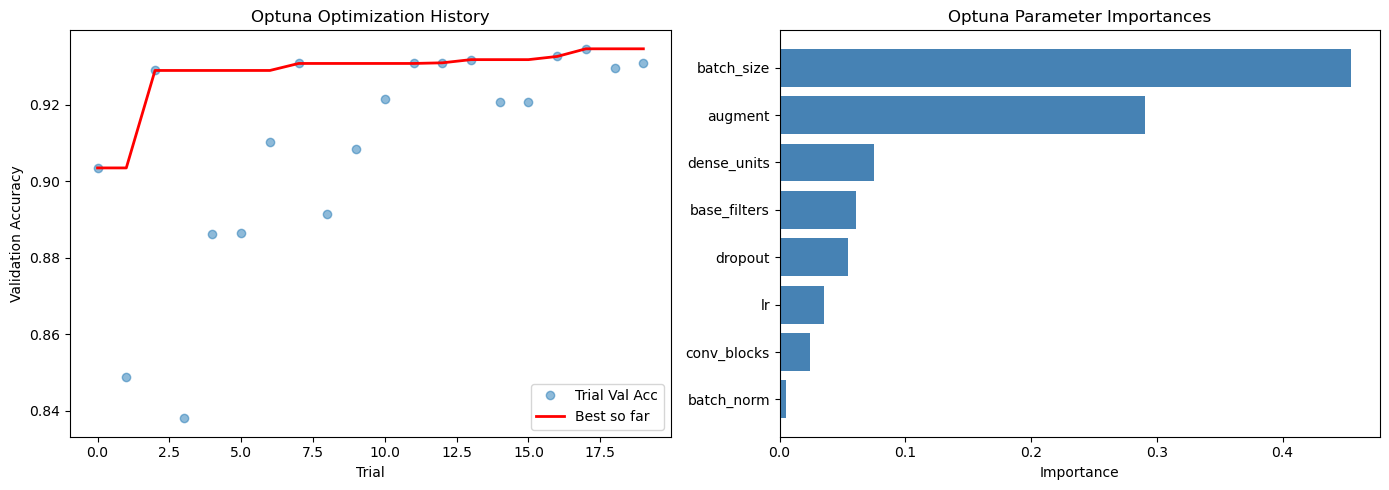


Top 5 trials:
 trial  val_acc  conv_blocks  base_filters  dense_units  dropout  batch_norm     lr  batch_size  augment
    17   0.9347            2            64          256   0.4746       False 0.0011         128    False
    16   0.9327            2            64          256   0.3611       False 0.0009         128    False
    13   0.9318            3            64          256   0.3560       False 0.0011         128    False
    12   0.9310            3            64          256   0.3418       False 0.0004         128    False
     7   0.9308            3            64          256   0.2697       False 0.0004         128    False


In [19]:
# optimization history: how best val accuracy improved over trials
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = np.maximum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(trial_values, "o", alpha=0.5, label="Trial Val Acc")
axes[0].plot(best_so_far, color="red", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Optuna Optimization History")
axes[0].legend()

# parameter importance (requires enough trials)
try:
    importances = optuna.importance.get_param_importances(study)
    params_list = list(importances.keys())
    imp_values  = list(importances.values())
    axes[1].barh(params_list[::-1], imp_values[::-1], color="steelblue")
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Optuna Parameter Importances")
except Exception:
    axes[1].text(0.5, 0.5, "Not enough trials for importance", ha="center", va="center")

plt.tight_layout()
plt.show()

# top 5 trials
trial_df = pd.DataFrame(
    [{"trial": t.number, "val_acc": t.value, **t.params}
     for t in sorted(study.trials, key=lambda t: t.value or 0, reverse=True)[:5]]
).round(4)
print("\nTop 5 trials:")
print(trial_df.to_string(index=False))

## Section 6 — Final Model Evaluation

The best Optuna configuration is now retrained on the **full 60,000 training images** (not just the 54,000 experiment split). A 10% validation split from this training run is used only for monitoring training curves — it does not influence model selection. The held-out test set (10,000 images) is evaluated exactly once.

In [20]:
best = study.best_params
print("Rebuilding best configuration:")
for k, v in best.items():
    print(f"  {k}: {v}")

tf.random.set_seed(42)
final_model = build_cnn(
    conv_blocks  = best["conv_blocks"],
    base_filters = best["base_filters"],
    dense_units  = best["dense_units"],
    dropout      = best["dropout"],
    batch_norm   = best["batch_norm"],
    lr           = best["lr"],
    augment      = best["augment"]
)
final_model.summary()

Rebuilding best configuration:
  conv_blocks: 2
  base_filters: 64
  dense_units: 256
  dropout: 0.4745726781984926
  batch_norm: False
  lr: 0.0010505272146667112
  batch_size: 128
  augment: False


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,682,954 (6.42 MB)

 Trainable params: 1,682,954 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

Final model stopped at epoch 19


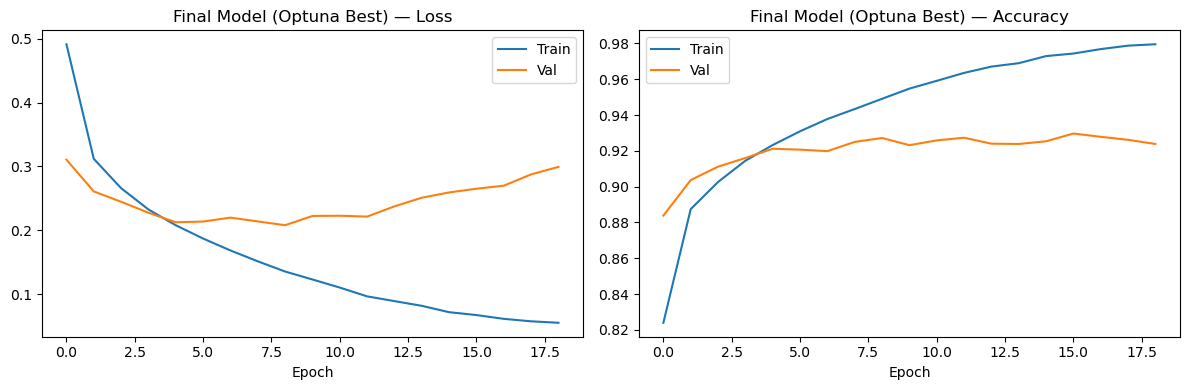

In [21]:
final_es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

final_history = final_model.fit(
    X_train_full, y_train_full,          # all 60k training images
    epochs=50,
    batch_size=best["batch_size"],
    validation_split=0.1,                # 10% for monitoring only
    callbacks=[final_es],
    verbose=0
)

print(f"Final model stopped at epoch {len(final_history.history['loss'])}")
plot_history(final_history, title="Final Model (Optuna Best)")

In [22]:
# evaluate exactly once on the held-out test set
final_loss, final_acc = final_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Final Test Accuracy : {final_acc:.4f}")
print(f"Final Test Loss     : {final_loss:.4f}")
print()

y_pred_prob = final_model.predict(X_test_cnn, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Final Test Accuracy : 0.9234
Final Test Loss     : 0.2297

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.91      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.86      0.88      1000
       Dress       0.93      0.92      0.93      1000
        Coat       0.83      0.94      0.88      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.84      0.70      0.76      1000
     Sneaker       0.97      0.96      0.97      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.97      0.98      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



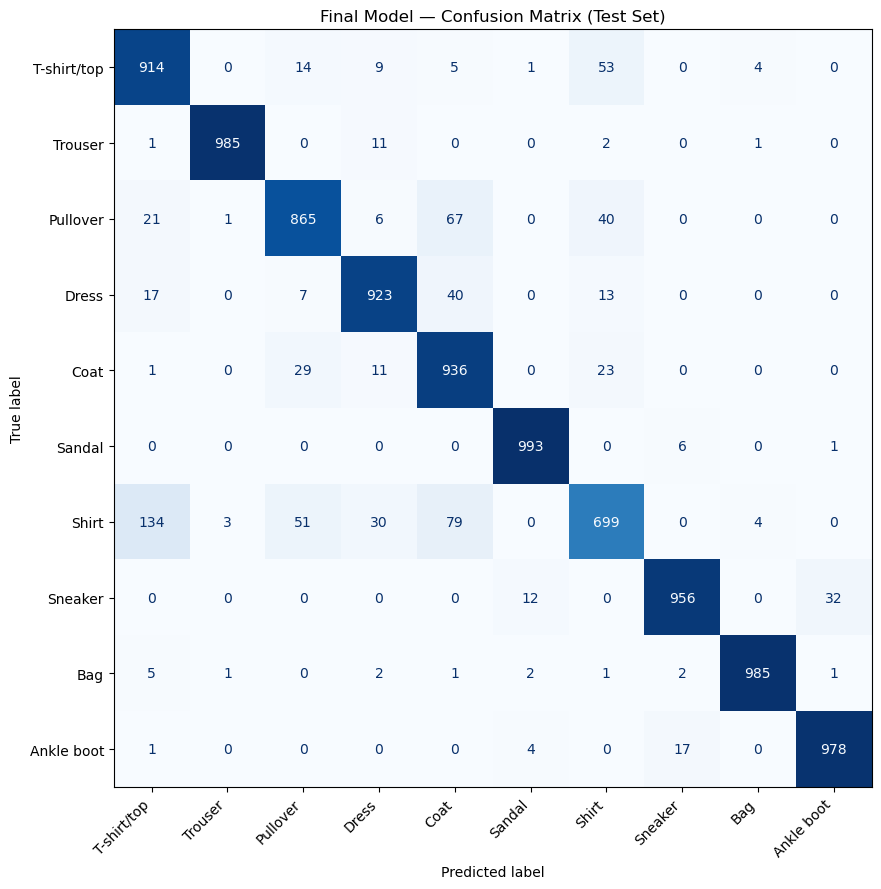


Per-class accuracy (sorted ascending):
Shirt          0.699
Pullover       0.865
T-shirt/top    0.914
Dress          0.923
Coat           0.936
Sneaker        0.956
Ankle boot     0.978
Trouser        0.985
Bag            0.985
Sandal         0.993
dtype: float64


In [23]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.title("Final Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_series = pd.Series(per_class_acc, index=CLASS_NAMES).round(4).sort_values()
print("\nPer-class accuracy (sorted ascending):")
print(acc_series)

In [24]:
# aggregate comparison across all models tested
results_summary = pd.DataFrame([
    {"Model": "Baseline (1 block, 32 filters)",        "Val Acc": depth_results["1 block (baseline)"]["val_acc"]},
    {"Model": "2-block CNN (Exp A)",                   "Val Acc": depth_results["2 blocks"]["val_acc"]},
    {"Model": "3-block CNN (Exp A)",                   "Val Acc": depth_results["3 blocks"]["val_acc"]},
    {"Model": f"2-block, best filter (Exp B)",         "Val Acc": max(v["val_acc"] for v in filter_results.values())},
    {"Model": f"2-block, best dropout (Exp C)",        "Val Acc": max(v["val_acc"] for v in dropout_results.values())},
    {"Model": f"2-block + augmentation (Exp D)",       "Val Acc": aug_results["With augmentation"]["val_acc"]},
    {"Model": f"Optuna Final (test acc)",              "Val Acc": final_acc},
]).sort_values("Val Acc", ascending=False).reset_index(drop=True)

results_summary["Val Acc"] = results_summary["Val Acc"].round(4)
print(results_summary.to_string(index=False))

                         Model  Val Acc
 2-block, best dropout (Exp C)   0.9297
       Optuna Final (test acc)   0.9234
  2-block, best filter (Exp B)   0.9187
Baseline (1 block, 32 filters)   0.9127
           2-block CNN (Exp A)   0.9127
           3-block CNN (Exp A)   0.9067
2-block + augmentation (Exp D)   0.8997


**Final model observations:**

Optuna found the best configuration after 20 trials: **2 conv blocks, 64 base filters (64→128), 256-unit dense head, dropout=0.47, no batch norm, lr=0.00105, batch_size=128, no augmentation**. This reached 93.5% on the validation set during tuning and **92.3% on the held-out test set**.

The configuration directly reflects what the controlled experiments found:
- **2 blocks, not 3:** consistent with Exp A — the third block collapses spatial maps to 3×3 without helping.
- **64 base filters (not 32):** Exp B showed 64 filters overfit when dropout=0.0, but Optuna paired it with a dropout rate of 0.47, which contains the overfitting. More capacity + stronger regularization is the winning combination, not less capacity.
- **No augmentation:** confirms Exp D's finding that augmentation hurts on this standardized dataset. All 5 of the top Optuna trials used augment=False.
- **Dropout ~0.47:** heavier than the 0.2 optimum from Exp C because the larger architecture (64 filters, 256-unit head) needs stronger regularization. The relationship between capacity and regularization strength is not fixed — it depends on model size.

**Per-class test performance:**

| Class | F1 | Note |
|---|---|---|
| Shirt | 0.76 | Worst — 30% of shirts predicted as T-shirt/top or Coat |
| T-shirt/top | 0.87 | Second-worst — rectangular silhouette overlaps with Shirt |
| Pullover / Coat | 0.88 | Similar upper-body garment shapes |
| Sneaker / Ankle boot / Sandal | 0.97–0.99 | Footwear classes are well-separated |
| Trouser / Bag | 0.99 | Unique silhouettes; nearly perfect |

The Shirt class is the clear weak point — its recall of 70% means the model misses 30% of actual Shirts. This is a known Fashion MNIST challenge: Shirt, T-shirt/top, and Coat share similar rectangular outlines, and the distinguishing features (collar style, hemline, sleeve length) are subtle at 28×28 resolution. These confusions would benefit most from higher resolution images or pre-trained feature extractors, not more tuning of this architecture.

**Comparison summary:**

| Model | Val/Test Acc | Note |
|---|---|---|
| 2-block + dropout=0.2 (Exp C) | 0.9297 (val) | Best val acc of manual experiments |
| Optuna Final | 0.9234 (test) | Evaluated on a different held-out set |
| 2-block, 32→64 filters (Exp B) | 0.9187 (val) | Best without regularization |
| Baseline (1 block) | 0.9127 (val) | Starting point |
| 2-block + augmentation (Exp D) | 0.8997 (val) | Augmentation hurt on this dataset |

The Optuna test accuracy (0.9234) and the Exp C val accuracy (0.9297) are measured on different sets and are not directly comparable. What matters is that the final model achieves a real +1 pp improvement over the no-regularization baseline on a fully held-out set, confirming that the systematic tuning approach produced a genuinely better generalizing model.

## Section 7 — Personal Workflow

A practical reference for building and tuning CNN models in future projects, built from what worked and what caused problems in this assignment.

---

### Step 1: Understand the data before writing a single layer

Before building any model:
- Check shapes, pixel ranges, and class balance. For CNNs, `(N, H, W)` images need a channel dimension added: `X[..., np.newaxis]`.
- Normalize pixel values. CNNs are not scale-invariant; `/ 255.0` brings all inputs to [0, 1] and keeps gradients stable.
- Visualize samples per class — this reveals inter-class similarity that predicts where the model will struggle. If Shirt and T-shirt look nearly identical to a human, expect the model to confuse them too.
- Check class balance. If balanced (like Fashion MNIST), accuracy is a fine metric. If skewed, switch to macro F1 or weighted accuracy immediately so imbalanced classes don't hide in aggregated scores.

---

### Step 2: Build the simplest baseline that actually uses convolutions

The first CNN should be: one Conv2D block → MaxPooling → Flatten → Dense → softmax. Train it for up to 30 epochs with `EarlyStopping(patience=5)`. The goal is not a good result — it is to confirm the data pipeline is correct and establish a performance floor. A baseline that takes 30 seconds to build and reaches 88% accuracy tells you far more than a complex model that took 2 hours.

**What to look at first:** the training curves. Train and val accuracy tracking closely with no divergence = no overfitting. Large and growing gap = overfit. Both flat and low = underfit. Diagnose before changing anything.

---

### Step 3: One factor at a time, in priority order

Change hyperparameters one at a time so you know what caused any change in performance:

1. **Architecture depth** first — this is the single biggest lever for CNNs. Adding a second conv block allows the network to compose low-level edge detectors into mid-level texture and shape features. For images under ~100×100 pixels, 2–3 blocks is usually the practical ceiling before maxpooling collapses the spatial representation too aggressively.
2. **Filter count** second — varies capacity without changing depth. More filters = more feature detectors per layer, but parameter count grows quadratically. For small datasets (< 100k images), 32–64 filters per block is typically sufficient.
3. **Regularization** third — only after capacity is roughly right. Dropout on the dense head is the cheapest fix for a large train-val gap. Batch normalization after conv layers often helps convergence more than it helps generalization, but it makes the model less sensitive to learning rate choice.
4. **Augmentation** last among single-factor changes — it is the most expensive (slows training) and its benefit depends on whether the test distribution actually includes the transformations you apply. Horizontal flip is almost always safe for object classification. Large rotations may not be valid for class-discriminating features (an upside-down shoe is not a valid shoe).

---

### Step 4: Systematic tuning with Optuna

Once the experiments reveal which factors matter, Optuna explores the joint space efficiently:
- Use a **fixed held-out validation set** (not validation_split, which varies with data order) so all trials are compared on identical data.
- **Optimize validation accuracy**, not training accuracy or loss. Training loss will always improve with more capacity.
- Set `EarlyStopping(patience=5)` inside each trial. This makes poor configurations terminate in a few epochs rather than running to completion — a 10× speedup on wasted trials.
- 20–30 trials is enough to see clear improvement over manual search on tabular/image datasets of this scale. The `parameter_importances` plot after Optuna tells you which factors actually mattered — if `batch_size` has near-zero importance, you can remove it from future searches.
- **Never evaluate the test set during tuning.** The test set is a single held-out evaluation at the very end. Looking at it during development and adjusting in response is a form of data leakage that inflates reported performance.

---

### Step 5: Final evaluation

After Optuna, retrain the best configuration on the **full training set** (including the validation split used during tuning). Then evaluate once on the test set and report:
- **Classification report** (precision, recall, F1 per class) — the confusion matrix reveals which class pairs the model struggles with most.
- **Training curves** — confirms the model converged without overfitting during the final training run.
- **Comparison table** — show the baseline and each experimental improvement side by side so the narrative is clear.

---

### Pitfalls worth remembering

| Symptom | Likely cause | Fix |
|---|---|---|
| Val accuracy never improves | Images not normalized | Check `/255.0` |
| NaN loss from epoch 1 | Learning rate too high | Drop lr by 10× |
| Training accuracy stalls at ~10% | Label encoding wrong | Verify `sparse_categorical_crossentropy` + integer labels |
| 3 blocks worse than 2 | Feature maps too small after 3 MaxPool | Check spatial dims; use `padding='same'` |
| Augmentation hurts val acc | Wrong augmentation for this domain | Verify flips/rotations are class-preserving |
| Optuna picks same config repeatedly | Search space too narrow | Widen lr range or add more options |